In [1]:
!kaggle datasets download shaunthesheep/microsoft-catsvsdogs-dataset

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
100% 788M/788M [00:09<00:00, 91.1MB/s]



In [2]:
import zipfile
zip_ref = zipfile.ZipFile('/content/microsoft-catsvsdogs-dataset.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [3]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [4]:
import os
import tensorflow as tf

data_dir = '/content/PetImages'
removed_count = 0

# Scan all files using TensorFlow's own strict decoder
for root, dirs, files in os.walk(data_dir):
    for file in files:
        file_path = os.path.join(root, file)

        # Skip hidden files
        if file.startswith('.'):
            continue

        try:
            # 1. Read the raw file bytes
            raw_img = tf.io.read_file(file_path)
            # 2. Force TensorFlow to decode it as a JPEG/PNG image
            tf.io.decode_image(raw_img, channels=3, expand_animations=False)
        except tf.errors.InvalidArgumentError:
            # If TensorFlow crashes trying to read it, delete it
            print(f"TensorFlow rejected and removed: {file_path}")
            os.remove(file_path)
            removed_count += 1

print(f"Cleanup finished. Total bad images removed by TensorFlow: {removed_count}")



TensorFlow rejected and removed: /content/PetImages/Dog/11702.jpg
TensorFlow rejected and removed: /content/PetImages/Dog/2494.jpg
TensorFlow rejected and removed: /content/PetImages/Dog/11912.jpg
TensorFlow rejected and removed: /content/PetImages/Dog/2317.jpg
TensorFlow rejected and removed: /content/PetImages/Dog/11233.jpg
TensorFlow rejected and removed: /content/PetImages/Dog/Thumbs.db
TensorFlow rejected and removed: /content/PetImages/Dog/9500.jpg
TensorFlow rejected and removed: /content/PetImages/Cat/666.jpg
TensorFlow rejected and removed: /content/PetImages/Cat/Thumbs.db
TensorFlow rejected and removed: /content/PetImages/Cat/10404.jpg
TensorFlow rejected and removed: /content/PetImages/Cat/4351.jpg
Cleanup finished. Total bad images removed by TensorFlow: 11


In [5]:
import tensorflow as tf

data_dir = '/content/PetImages'
batch_size = 32
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(150, 150),
    batch_size=batch_size
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(150, 150),
    batch_size=batch_size
)


Found 24991 files belonging to 2 classes.
Using 19993 files for training.
Found 24991 files belonging to 2 classes.
Using 4998 files for validation.


In [6]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
train_ds = train_ds.map(lambda x, y: (x / 255.0, y))

validation_ds = validation_ds.map(lambda x, y: (x / 255.0, y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [7]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(150,150,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
from keras.layers import Dropout
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.35))
model.add(Dense(1,activation='sigmoid'))


In [9]:
conv_base.trainable = False

In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [11]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [12]:
from keras.callbacks import EarlyStopping
early_stop=EarlyStopping(monitor='val_loss',patience=2,restore_best_weights=True)

In [13]:
history = model.fit(
        train_ds,
        epochs=10,
        validation_data=validation_ds,callbacks=[early_stop])

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 195s 297ms/step - accuracy: 0.8075 - loss: 0.4188 - val_accuracy: 0.8956 - val_loss: 0.2346
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 89s 143ms/step - accuracy: 0.8467 - loss: 0.3422 - val_accuracy: 0.9030 - val_loss: 0.2292
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 144ms/step - accuracy: 0.8645 - loss: 0.3121 - val_accuracy: 0.9028 - val_loss: 0.2276
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 144ms/step - accuracy: 0.8706 - loss: 0.2963 - val_accuracy: 0.9036 - val_loss: 0.2278
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 144ms/step - accuracy: 0.8784 - loss: 0.2772 - val_accuracy: 0.9066 - val_loss: 0.2249
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 89s 143ms/step - accuracy: 0.8885 - loss: 0.2603 - val_accuracy: 0.9074 - val_loss: 0.2251
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 143ms/step - accuracy: 0.8929 - loss: 0.2518 - val_accuracy: 0.9050 - val_loss: 0.2375


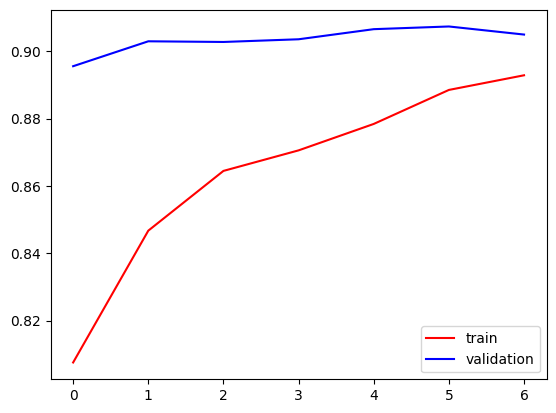

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

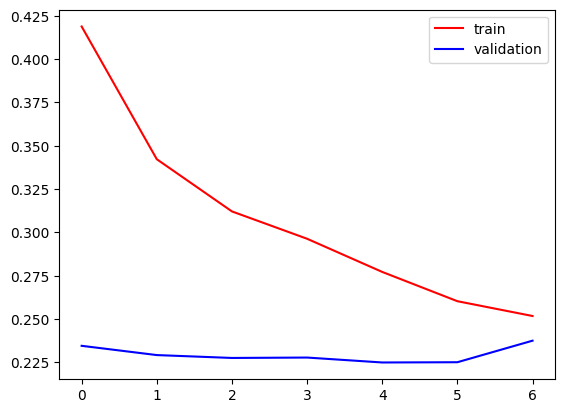

In [15]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


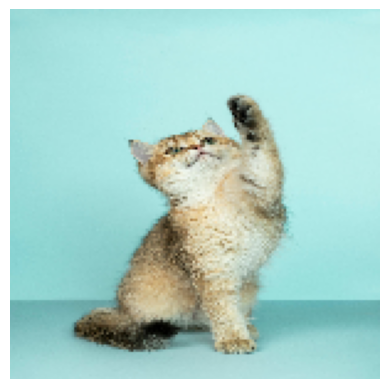

In [21]:
import numpy as np

img = tf.keras.utils.load_img('/content/cat.jpg', target_size=(150, 150))
img_array = tf.keras.utils.img_to_array(img)

img_array = tf.expand_dims(img_array, 0)
img_array = img_array / 255.0

prediction=model.predict(img_array)


import matplotlib.pyplot as plt
plt.imshow(img)
plt.axis('off')
plt.show()

In [26]:
if prediction[0][0]>0.5:
   confidence=(prediction[0][0])*100
   print('Dog')
   print("Confidence=",confidence)
else:
   confidence=(1-prediction[0][0])*100
   print('Cat')
   print("Confidence=",confidence)

Cat
Confidence= 86.22594
